In [6]:
import os
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [3]:
class SpectrogramDataset(Dataset):
    def __init__(self, input_dir, target_dir, transform=None):
        self.input_files = sorted([os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.png')])
        self.target_files = sorted([os.path.join(target_dir, f) for f in os.listdir(target_dir) if f.endswith('.png')])
        self.transform = transform

    def __len__(self):
        return len(self.input_files)

    def __getitem__(self, idx):
        input_img = Image.open(self.input_files[idx]).convert('RGB')
        target_img = Image.open(self.target_files[idx]).convert('RGB')

        if self.transform:
            input_img = self.transform(input_img)
            target_img = self.transform(target_img)

        return input_img, target_img

# Transformações
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Ajustar tamanho
    transforms.ToTensor(),         # Converter para tensor
])

# Dataset e DataLoader
train_dataset = SpectrogramDataset("../spectrograms/train/input", "../spectrograms/train/target", transform=transform)
val_dataset = SpectrogramDataset("../spectrograms/val/input", "../spectrograms/val/target", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


In [4]:
import torch
import torch.nn as nn

class SimpleAutoencoder(nn.Module):
    def __init__(self):
        super(SimpleAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [5]:
import torch.optim as optim

# Inicializar modelo, perda e otimizador
if torch.cuda.is_available()
    print("using cuda")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Loop de treinamento
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    val_loss = 0.0
    model.eval()
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")


Epoch [1/100], Train Loss: 0.0629, Val Loss: 0.0358
Epoch [2/100], Train Loss: 0.0298, Val Loss: 0.0239
Epoch [3/100], Train Loss: 0.0196, Val Loss: 0.0158
Epoch [4/100], Train Loss: 0.0139, Val Loss: 0.0125
Epoch [5/100], Train Loss: 0.0110, Val Loss: 0.0094
Epoch [6/100], Train Loss: 0.0085, Val Loss: 0.0078
Epoch [7/100], Train Loss: 0.0071, Val Loss: 0.0068
Epoch [8/100], Train Loss: 0.0063, Val Loss: 0.0062
Epoch [9/100], Train Loss: 0.0058, Val Loss: 0.0058
Epoch [10/100], Train Loss: 0.0054, Val Loss: 0.0054
Epoch [11/100], Train Loss: 0.0051, Val Loss: 0.0052
Epoch [12/100], Train Loss: 0.0049, Val Loss: 0.0052
Epoch [13/100], Train Loss: 0.0048, Val Loss: 0.0049
Epoch [14/100], Train Loss: 0.0046, Val Loss: 0.0048
Epoch [15/100], Train Loss: 0.0046, Val Loss: 0.0047
Epoch [16/100], Train Loss: 0.0044, Val Loss: 0.0046
Epoch [17/100], Train Loss: 0.0043, Val Loss: 0.0044
Epoch [18/100], Train Loss: 0.0043, Val Loss: 0.0044
Epoch [19/100], Train Loss: 0.0042, Val Loss: 0.0044
Ep

In [6]:
torch.save(model.state_dict(), "autoencoder_model.pth")

In [7]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, device, save_dir="results"):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    with torch.no_grad():
        for idx, (inputs, targets) in enumerate(dataloader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            # Salvar imagens
            for i in range(len(inputs)):
                plt.figure(figsize=(15, 5))
                
                # Entrada
                plt.subplot(1, 3, 1)
                plt.imshow(inputs[i].permute(1, 2, 0).cpu().numpy())
                plt.title("Entrada")
                plt.axis('off')
                
                # Alvo
                plt.subplot(1, 3, 2)
                plt.imshow(targets[i].permute(1, 2, 0).cpu().numpy())
                plt.title("Alvo")
                plt.axis('off')
                
                # Saída
                plt.subplot(1, 3, 3)
                plt.imshow(outputs[i].permute(1, 2, 0).cpu().numpy())
                plt.title("Saída")
                plt.axis('off')

                plt.tight_layout()
                plt.savefig(os.path.join(save_dir, f"prediction_{idx}_{i}.png"))
                plt.close()

# Chamar a função de visualização
visualize_predictions(model, val_loader, device)


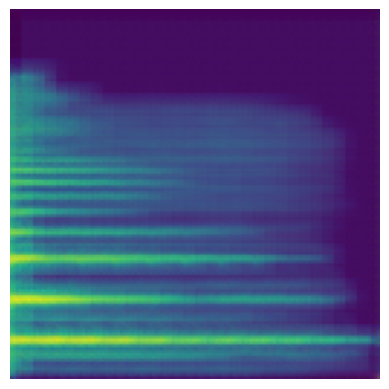

In [10]:
from PIL import Image
import torch

def predict_with_model(model, input_spectrogram_path, device):
    # Carregar e processar o espectrograma
    image = Image.open(input_spectrogram_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ])
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Fazer a predição
    model.eval()
    with torch.no_grad():
        output_tensor = model(input_tensor)

    return output_tensor.squeeze(0).cpu()

# Exemplo de uso
output = predict_with_model(model, "../spectrograms/train/input/1-0.png", device)

# Salvar resultado
plt.imshow(output.permute(1, 2, 0))
plt.axis('off')
plt.savefig("generated_output.png")


In [3]:
import soundfile as sf

def spectrogram_to_audio(spectrogram, sr=16000, n_fft=2048, hop_length=512):
    # Reverter espectrograma Mel para amplitude
    mel_db = librosa.db_to_power(spectrogram, ref=1.0)
    audio = librosa.feature.inverse.mel_to_audio(mel_db, sr=sr, n_fft=n_fft, hop_length=hop_length)
    return audio




In [ ]:
# Gerar áudio
output_audio = spectrogram_to_audio(output[0].numpy())

# Salvar áudio usando soundfile
sf.write("../output/output_audio.wav", output_audio, 16000)

In [7]:
import numpy as np
import os

def png_to_npy(input_path, output_path):
    """
    Converte imagens de espectrogramas PNG para arrays NumPy salvos como arquivos .npy.

    Args:
        input_path (str): Caminho para o arquivo contendo as imagens PNG.
        output_path (str): Caminho para salvar os arquivos .npy.
    """
    os.makedirs(output_path, exist_ok=True)
    

    if input_path.endswith('.png'):
        try:
            # Abrir imagem usando Pillow
            img = Image.open(input_path)
            
            # Converter a imagem para um array NumPy
            img_array = np.array(img)
            
            # Salvar o array NumPy como arquivo .npy
            npy_file = os.path.join(output_path, input_path.replace('.png', '.npy'))
            np.save(npy_file, img_array)
            
            print(f"Convertido para .npy: {npy_file}")
        except Exception as e:
            print(f"Erro ao converter {input_path}: {e}")
            
png_to_npy('../spectrograms/train/input/1-0.png', "../output")

Convertido para .npy: ../output\../spectrograms/train/input/1-0.npy


In [29]:
import librosa
def process_spectrogram_folder(input_file, output_path, sr=16000, n_fft=64, hop_length=64):


    if input_file.endswith('.npy'):
        # Carregar espectrograma Mel
        spectrogram = np.load(input_file)
        
        # Converter para áudio
        audio = spectrogram_to_audio(spectrogram, sr=sr, n_fft=n_fft, hop_length=hop_length)
        
        # Salvar como arquivo WAV
        sf.write('output.wav', np.ravel(audio), sr)
        print(f"Áudio salvo: {'output.wav'}")

process_spectrogram_folder('../output/1-0.npy', '../output/output.wav')

Áudio salvo: output.wav
